# Final Update: Applying NER

In [1]:
import spacy
import numpy as np
import pandas as pd

nlp_ner = spacy.load("en_core_web_sm", disable=["tagger", "parser", "lemmatizer", "attribute_ruler"])

In [2]:
def extract_entity_sets_batch(texts, batch_size=64):
    texts = [str(t) if pd.notna(t) else "" for t in texts]
    out = []

    for i, doc in enumerate(nlp_ner.pipe(texts, batch_size=batch_size), start=1):
        ents = {ent.text.lower().strip() for ent in doc.ents if ent.text.strip()}
        out.append(ents)

        if i % 1000 == 0:
            print(f"NER processed {i}/{len(texts)}")

    return out

In [3]:
def entity_metrics(a, b):
    # a = T0 entities, b = Tx entities
    if len(a) == 0:
        return (np.nan, np.nan, np.nan)

    inter = len(a & b)
    union = len(a | b)

    jaccard = inter / union if union > 0 else np.nan
    recall = inter / len(a) if len(a) > 0 else np.nan
    precision = inter / len(b) if len(b) > 0 else np.nan

    return jaccard, recall, precision

In [5]:
import pandas as pd
from pathlib import Path

ROOT = Path("..").resolve()
OUT_DIR = ROOT / "experiments" / "stylometry_results"

models = [
    "chatgpt",
    "palm",
    "dipper(high)",
    "dipper(low)",
    "pegasus(slight)",
    "pegasus(full)"
]

chains = {}
for m in models:
    fp = OUT_DIR / f"{m}_trajectory_pos.pkl"
    chains[m] = pd.read_pickle(fp)
    print(m, chains[m].shape)

chatgpt (19049, 18)
palm (16924, 18)
dipper(high) (19342, 18)
dipper(low) (19342, 18)
pegasus(slight) (19342, 18)
pegasus(full) (19328, 18)


In [6]:
for base, df_chain in chains.items():
    print(f"=== NER for {base} ===")

    df_chain["ent_T0"] = extract_entity_sets_batch(df_chain["T0"])
    df_chain["ent_T1"] = extract_entity_sets_batch(df_chain["T1"])
    df_chain["ent_T2"] = extract_entity_sets_batch(df_chain["T2"])
    df_chain["ent_T3"] = extract_entity_sets_batch(df_chain["T3"])

    chains[base] = df_chain

=== NER for chatgpt ===
NER processed 1000/19049
NER processed 2000/19049
NER processed 3000/19049
NER processed 4000/19049
NER processed 5000/19049
NER processed 6000/19049
NER processed 7000/19049
NER processed 8000/19049
NER processed 9000/19049
NER processed 10000/19049
NER processed 11000/19049
NER processed 12000/19049
NER processed 13000/19049
NER processed 14000/19049
NER processed 15000/19049
NER processed 16000/19049
NER processed 17000/19049
NER processed 18000/19049
NER processed 19000/19049
NER processed 1000/19049
NER processed 2000/19049
NER processed 3000/19049
NER processed 4000/19049
NER processed 5000/19049
NER processed 6000/19049
NER processed 7000/19049
NER processed 8000/19049
NER processed 9000/19049
NER processed 10000/19049
NER processed 11000/19049
NER processed 12000/19049
NER processed 13000/19049
NER processed 14000/19049
NER processed 15000/19049
NER processed 16000/19049
NER processed 17000/19049
NER processed 18000/19049
NER processed 19000/19049
NER pr

In [7]:
for base, df_chain in chains.items():
    print(f"=== entity metrics for {base} ===")

    vals_t1 = df_chain.apply(lambda row: entity_metrics(row["ent_T0"], row["ent_T1"]), axis=1)
    vals_t2 = df_chain.apply(lambda row: entity_metrics(row["ent_T0"], row["ent_T2"]), axis=1)
    vals_t3 = df_chain.apply(lambda row: entity_metrics(row["ent_T0"], row["ent_T3"]), axis=1)

    df_chain["jac_T1"] = vals_t1.apply(lambda x: x[0])
    df_chain["rec_T1"] = vals_t1.apply(lambda x: x[1])
    df_chain["pre_T1"] = vals_t1.apply(lambda x: x[2])

    df_chain["jac_T2"] = vals_t2.apply(lambda x: x[0])
    df_chain["rec_T2"] = vals_t2.apply(lambda x: x[1])
    df_chain["pre_T2"] = vals_t2.apply(lambda x: x[2])

    df_chain["jac_T3"] = vals_t3.apply(lambda x: x[0])
    df_chain["rec_T3"] = vals_t3.apply(lambda x: x[1])
    df_chain["pre_T3"] = vals_t3.apply(lambda x: x[2])

    chains[base] = df_chain

=== entity metrics for chatgpt ===
=== entity metrics for palm ===
=== entity metrics for dipper(high) ===
=== entity metrics for dipper(low) ===
=== entity metrics for pegasus(slight) ===
=== entity metrics for pegasus(full) ===


In [8]:
ner_rows = []

for base, df_chain in chains.items():
    ner_rows.append({
        "paraphraser": base,

        "rec_T1": np.nanmean(df_chain["rec_T1"]),
        "rec_T2": np.nanmean(df_chain["rec_T2"]),
        "rec_T3": np.nanmean(df_chain["rec_T3"]),

        "pre_T1": np.nanmean(df_chain["pre_T1"]),
        "pre_T2": np.nanmean(df_chain["pre_T2"]),
        "pre_T3": np.nanmean(df_chain["pre_T3"]),

        "jac_T1": np.nanmean(df_chain["jac_T1"]),
        "jac_T2": np.nanmean(df_chain["jac_T2"]),
        "jac_T3": np.nanmean(df_chain["jac_T3"]),
    })

ner_summary = pd.DataFrame(ner_rows)
ner_summary

,paraphraser,rec_T1,rec_T2,rec_T3,pre_T1,pre_T2,pre_T3,jac_T1,jac_T2,jac_T3
0,chatgpt,0.625585,0.591148,0.567910,0.764504,0.745511,0.729642,0.548952,0.514858,0.491362
1,palm,0.654506,0.599090,0.574840,0.793039,0.755065,0.737373,0.585248,0.526965,0.501155
2,dipper(high),0.040378,0.019270,0.012487,0.062617,0.042927,0.039672,0.022786,0.011198,0.007821
3,dipper(low),0.649713,0.565848,0.521775,0.733937,0.672556,0.643806,0.557721,0.474075,0.433236
4,pegasus(slight),0.888224,0.804278,0.737423,0.967033,0.941367,0.918788,0.868943,0.775524,0.703530
5,pegasus(full),0.559671,0.460785,0.417350,0.844933,0.800550,0.782121,0.518802,0.423819,0.383347


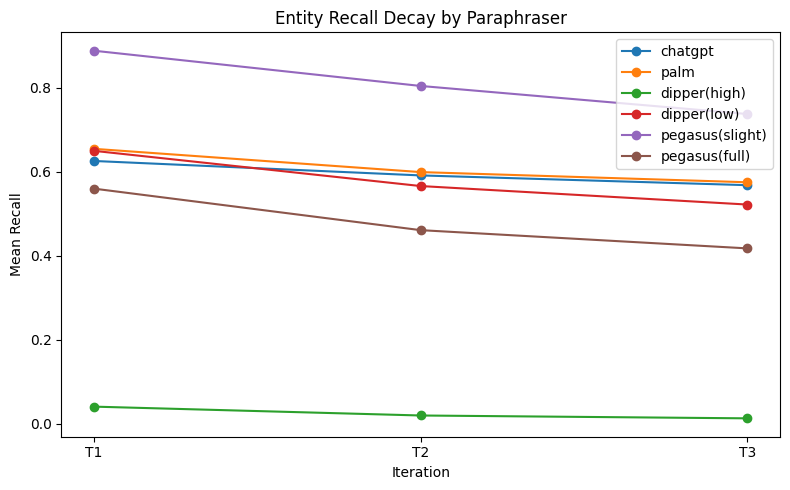

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for _, row in ner_summary.iterrows():
    plt.plot(
        ["T1", "T2", "T3"],
        [row["rec_T1"], row["rec_T2"], row["rec_T3"]],
        marker="o",
        label=row["paraphraser"]
    )

plt.title("Entity Recall Decay by Paraphraser")
plt.xlabel("Iteration")
plt.ylabel("Mean Recall")
plt.legend()
plt.tight_layout()
plt.show()